In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as const
from astropy.table import Table


In [166]:
img = np.loadtxt("../../aprilpark/homework11/astro_image.csv")

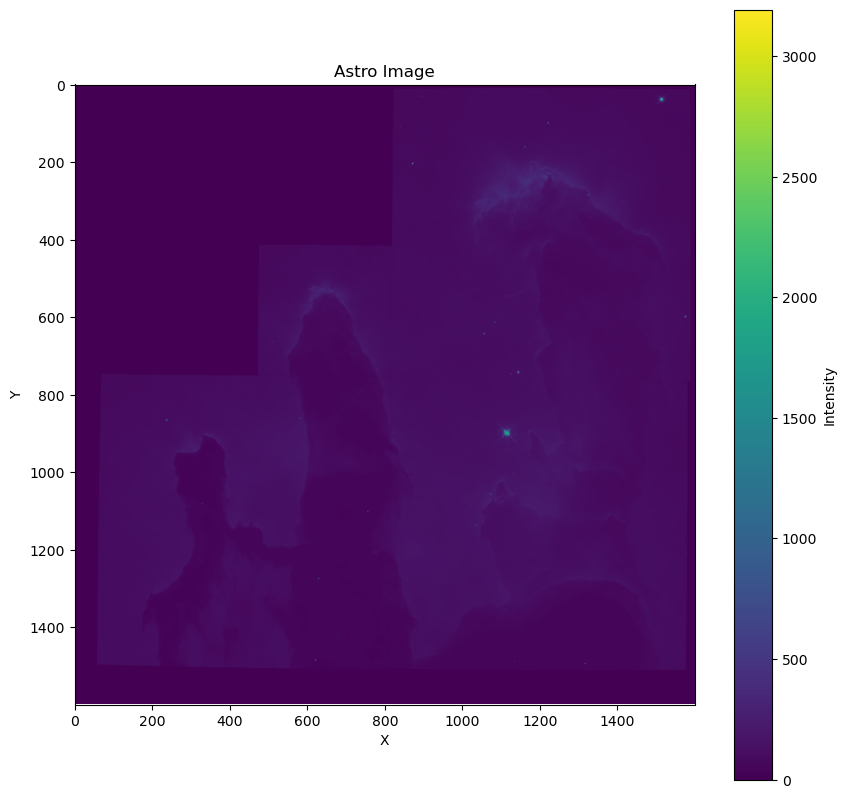

In [167]:
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.colorbar(label="Intensity")
plt.title("Astro Image")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

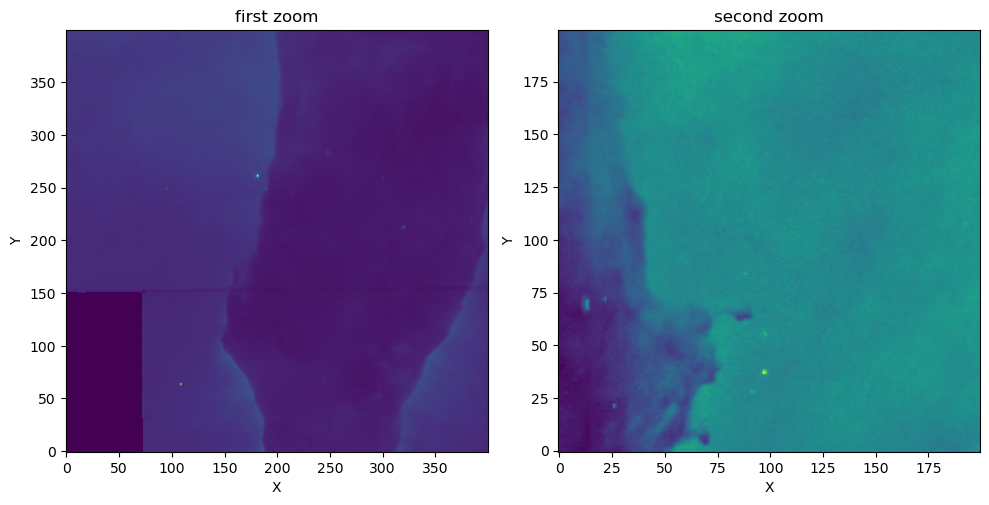

In [168]:
one = img[600:1000, 400:800]
two = img[1000:1200,800:1000]

fig,axes = plt.subplots(1,2, figsize=(10,10))





axes[0].imshow(one, origin="lower")
axes[0].set_title("first zoom")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

axes[1].imshow(two, origin="lower")
axes[1].set_title("second zoom")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

plt.tight_layout()
plt.show()


In [169]:
df = pd.read_csv("../../aprilpark/homework11/ramen-ratings.csv")

df.columns

Index(['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten'], dtype='object')

In [171]:
df.loc[26, 'Style'] #Pack


'Pack'

In [172]:
df['Brand'].nunique() #355 different ramen brands

355

In [173]:
sort = df.sort_values('Brand')
sort.head()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
229,2351,1 To 3 Noodles,Chatpat Masala,Pack,India,4,NaN
456,2124,7 Select,Nissin Instant Noodles Tom Yum Seafood Creamy ...,Bowl,Thailand,3.5,NaN
463,2117,7 Select,Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...,Bowl,Thailand,4,NaN
877,1703,7 Select/Nissin,Super Tom Yum Shrimp,Cup,Thailand,3.5,NaN
911,1669,A-One,Mi Ly Instant Noodles Mi Chay Vegetarian Flavor,Cup,Vietnam,1.25,NaN


In [174]:
df[df["Country"] == "USA"]['Brand'].nunique() #49 ramen brands made in the USA

49

In [176]:
df[(df["Country"] == "USA") &(df["Style"] == "Pack")]["Brand"].nunique() #27 pack-style ramen brands in the USA


27

In [177]:
file = "../../aprilpark/homework11/global_CCl4_MM.dat"
tab = Table.read(file, format='ascii')

In [178]:
df = tab.to_pandas()
df = df[['CCl4ottoyr', 'CCl4ottoGLm', 'CCl4ottoGLsd']]

In [179]:
df.head()

,CCl4ottoyr,CCl4ottoGLm,CCl4ottoGLsd
0,1996,NaN,NaN
1,1996,NaN,NaN
2,1996,NaN,NaN
3,1996,104.144,0.155
4,1996,103.893,0.174


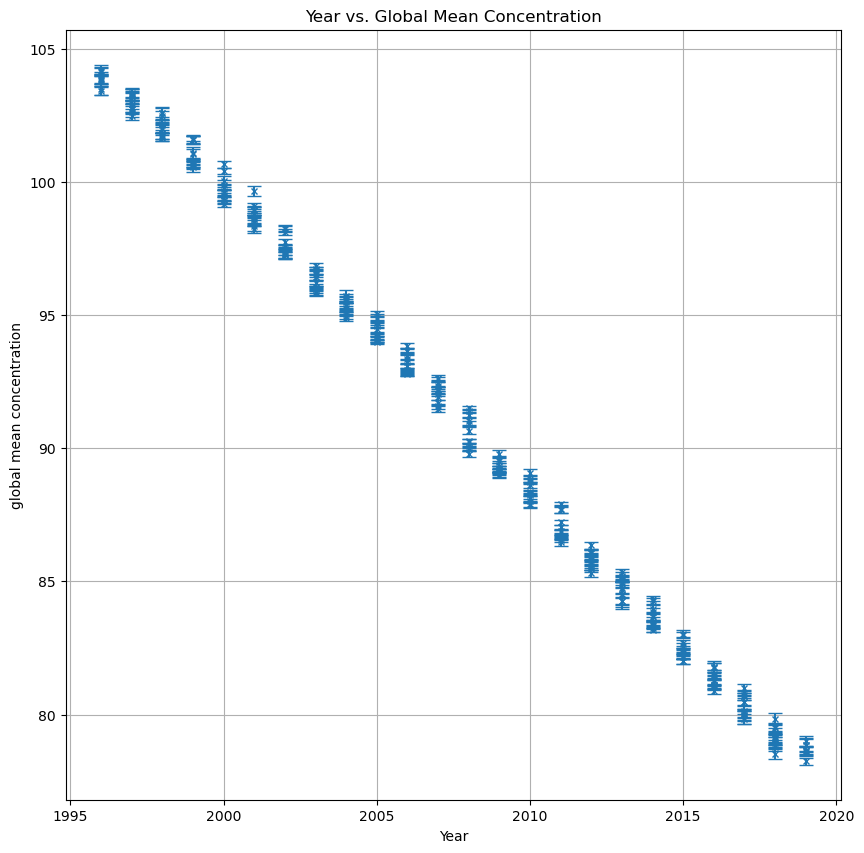

In [180]:
plt.figure(figsize = (10,10))
plt.errorbar(
    df["CCl4ottoyr"],
    df['CCl4ottoGLm'],
    yerr=df['CCl4ottoGLsd'],
    fmt = "x",
    markersize = 5,
    capsize = 5
)

plt.xlabel("Year")
plt.ylabel("global mean concentration")
plt.title("Year vs. Global Mean Concentration")
plt.grid(True)
plt.show()

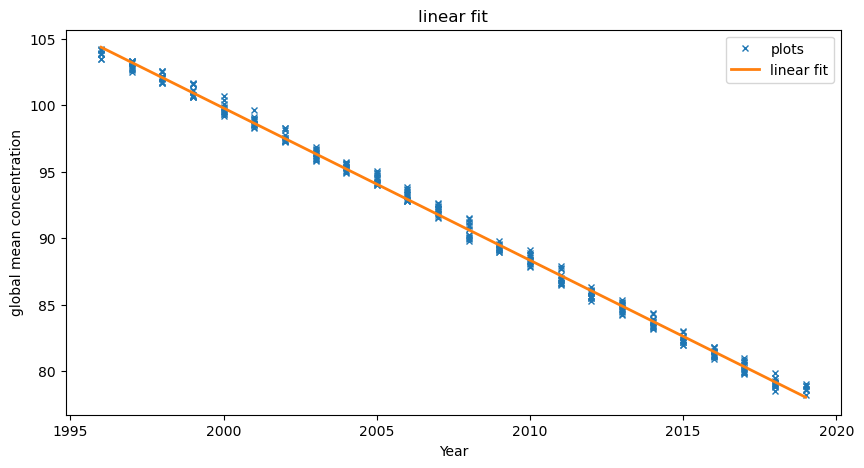

In [181]:
newdf = df.dropna()


x=newdf["CCl4ottoyr"].values
y=newdf['CCl4ottoGLm'].values
yerr = newdf['CCl4ottoGLsd'].values

m, b = np.polyfit(x, y, 1)


plt.figure(figsize=(10,5))
plt.plot(x, y, "x", markersize=5, label="plots")
plt.plot(x, m*x + b, label="linear fit", linewidth=2)

plt.xlabel("Year")
plt.ylabel("global mean concentration")
plt.title("linear fit")
plt.legend()
plt.show()

In [182]:
yexp = m*x + b
N = len(x)
chi_square = np.sum(((yexp - y) / yerr)**2) / (N-1)
chi_square

np.float64(13.309657001113733)

In [183]:
#The chi-square value came out as approximately 13. 309, which indicates that it is a poor fit and does not capture the model well